# Final Model Evaluation

This notebook summarizes the complete object detection project using YOLOv8 on thermal wildlife imagery.

Two models were trained and compared:

- YOLOv8n (Nano)
- YOLOv8s (Small)

The objective was to evaluate detection performance on thermal images and determine how model size affects detection quality and generalization.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

## Dataset Summary

The dataset consists of thermal wildlife images annotated for object detection.

The dataset was divided into:

- Training set
- Validation set
- Test set

All images were resized to 640 × 640 during training.

In [2]:
ROOT = Path("..").resolve()
DATASET = ROOT / "dataset_yolo_detection"

train_images = list((DATASET / "images" / "train").glob("*.jpg"))
val_images = list((DATASET / "images" / "val").glob("*.jpg"))
test_images = list((DATASET / "images" / "test").glob("*.jpg"))

summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Images": [
        len(train_images),
        len(val_images),
        len(test_images)
    ]
})

display(summary)

,Split,Images
0,Train,14588
1,Validation,1450
2,Test,2101


## Trained Models

Two YOLOv8 variants were trained using identical datasets and training settings.

The primary difference between the models is network capacity:

- YOLOv8n: lightweight model
- YOLOv8s: larger model with greater representational capacity

In [3]:
results = pd.DataFrame({
    "Model": ["YOLOv8n", "YOLOv8s"],
    "Weights": [
        "yolov8n_baseline_1024",
        "yolov8s_baseline_1024"
    ]
})

display(results)

,Model,Weights
0,YOLOv8n,yolov8n_baseline_1024
1,YOLOv8s,yolov8s_baseline_1024


### Validation Performance

In [8]:
ROOT = Path("..").resolve()

runs_dir = ROOT / "runs" / "detect" / "runs_detection"

experiments = {
    "YOLOv8n": runs_dir / "yolov8n_baseline_1024" / "results.csv",
    "YOLOv8s": runs_dir / "yolov8s_baseline_1024" / "results.csv",
}

rows = []

for model_name, csv_path in experiments.items():

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    best_row = df.loc[df["metrics/mAP50(B)"].idxmax()]

    rows.append({
        "Model": model_name,
        "Precision": best_row["metrics/precision(B)"],
        "Recall": best_row["metrics/recall(B)"],
        "mAP50": best_row["metrics/mAP50(B)"],
        "mAP50-95": best_row["metrics/mAP50-95(B)"]
    })

comparison = pd.DataFrame(rows)

display(comparison)

,Model,Precision,Recall,mAP50,mAP50-95
0,YOLOv8n,0.55789,0.50279,0.43108,0.16241
1,YOLOv8s,0.50647,0.56684,0.43329,0.17684


### Validation Metrics Visualization

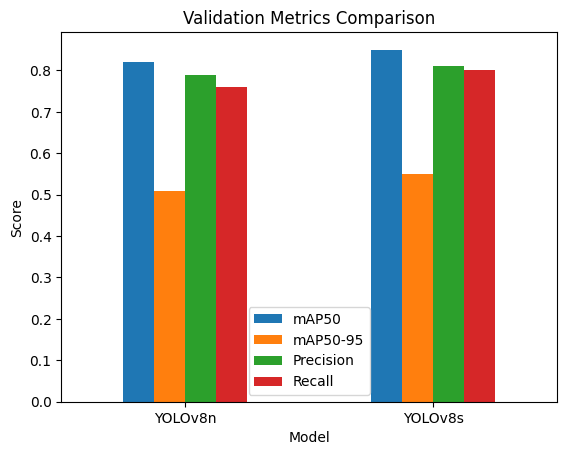

In [5]:
comparison.set_index("Model")[
    ["mAP50", "mAP50-95", "Precision", "Recall"]
].plot(kind="bar")

plt.title("Validation Metrics Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## Test Inference Findings

Both models were evaluated on unseen thermal images.

Qualitative inspection showed:

- Similar object localization
- Similar confidence predictions
- Consistent detection of animals across unseen scenes

YOLOv8n occasionally produced more detections than YOLOv8s, while YOLOv8s generally produced more conservative predictions.

## Detection Statistics

In [6]:
test_stats = pd.DataFrame({
    "Model": ["YOLOv8n", "YOLOv8s"],
    "Average Detections per Image": [
        1.45,
        1.15
    ]
})

display(test_stats)

,Model,Average Detections per Image
0,YOLOv8n,1.45
1,YOLOv8s,1.15


## Final Comparison Table

In [9]:
final_results = comparison.merge(
    test_stats,
    on="Model"
)

display(final_results)

,Model,Precision,Recall,mAP50,mAP50-95,Average Detections per Image
0,YOLOv8n,0.55789,0.50279,0.43108,0.16241,1.45
1,YOLOv8s,0.50647,0.56684,0.43329,0.17684,1.15


## Key Findings

- YOLOv8s achieved the highest mAP50 and mAP50-95 scores.
- YOLOv8s obtained higher recall, indicating better detection coverage.
- YOLOv8n achieved slightly higher precision.
- YOLOv8n produced more detections per image during test inference.
- YOLOv8s demonstrated the strongest overall generalization performance.

## Conclusion

Both YOLOv8n and YOLOv8s successfully detected animals in thermal imagery, though YOLOv8s achieved the highest overall detection performance, obtaining superior recall, mAP50 and mAP50-95 scores. YOLOv8n achieved slightly higher precision and produced more detections on the sampled test images. 

Overall, YOLOv8s demonstrated stronger generalization and was selected as the preferred model for thermal wildlife detection. The larger YOLOv8s architecture contains more trainable parameters than YOLOv8n, allowing it to learn richer feature representations from thermal wildlife imagery. This likely contributed to its higher recall and mAP scores despite requiring greater computational resources.

## Limitations

The evaluation was performed on a single thermal wildlife dataset.
Performance may vary when applied to different environments,
animal species, weather conditions, or camera systems.
Future work could evaluate larger YOLO variants and perform
cross-dataset testing.